# Diabetes Dataset: KNN Classification with Hyperparameter Tuning

This notebook performs comprehensive analysis and KNN classification on the diabetes dataset to predict whether a person has diabetes (Outcome: 1) or not (Outcome: 0).

## 1. Import Required Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load and Explore Data

In [2]:
# Load data
data_path = os.path.join('..', 'data', 'diabetes.csv')
df = pd.read_csv(data_path)

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())
print('\nColumn names and types:')
print(df.dtypes)

Dataset Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Column names and types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunctio

In [3]:
# Data Overview
print('Dataset Information:')
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
print('\nTarget Variable Distribution:')
print(df['Outcome'].value_counts())
print('\nTarget Variable Percentage:')
print(df['Outcome'].value_counts(normalize=True) * 100)
print('\nBasic Statistics:')
print(df.describe())

Dataset Information:
Shape: (768, 9)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Target Variable Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Target Variable Percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Basic Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%  

## 3. Data Cleaning

In [4]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Dropped {duplicates} duplicate rows')
    print(f'New shape: {df.shape}')

# Handle zero values in certain columns (they might be missing values represented as 0)
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    zero_count = (df[col] == 0).sum()
    print(f'\n{col} - Zero values: {zero_count}')
    
    # Replace zeros with median for these columns (as they are likely missing values)
    if zero_count > 0:
        median_value = df[df[col] != 0][col].median()
        df[col] = df[col].replace(0, median_value)
        print(f'  Replaced 0s with median: {median_value}')

print('\nData cleaning completed')

Duplicate rows: 0

Glucose - Zero values: 5
  Replaced 0s with median: 117.0

BloodPressure - Zero values: 35
  Replaced 0s with median: 72.0

SkinThickness - Zero values: 227
  Replaced 0s with median: 29.0

Insulin - Zero values: 374
  Replaced 0s with median: 125.0

BMI - Zero values: 11
  Replaced 0s with median: 32.3

Data cleaning completed


## 4. Exploratory Data Analysis (EDA)

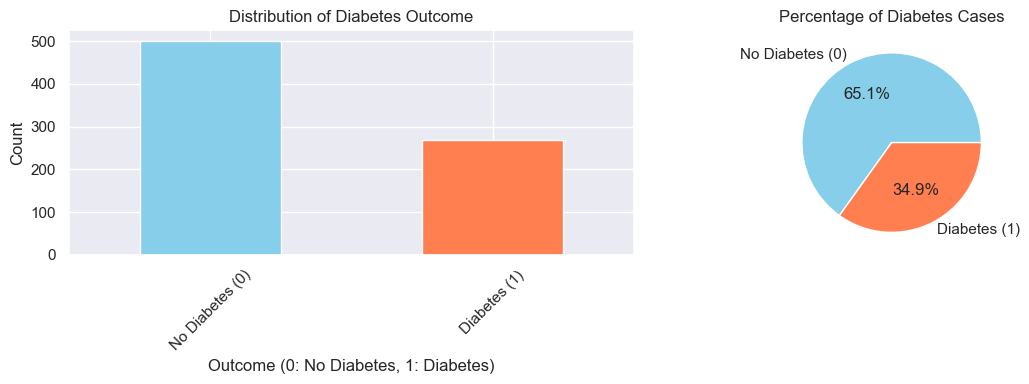

Target variable distribution analyzed


In [5]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['Outcome'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'coral'])
axes[0].set_title('Distribution of Diabetes Outcome')
axes[0].set_xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'], rotation=45)

# Pie chart
df['Outcome'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                    labels=['No Diabetes (0)', 'Diabetes (1)'],
                                    colors=['skyblue', 'coral'])
axes[1].set_title('Percentage of Diabetes Cases')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('Target variable distribution analyzed')

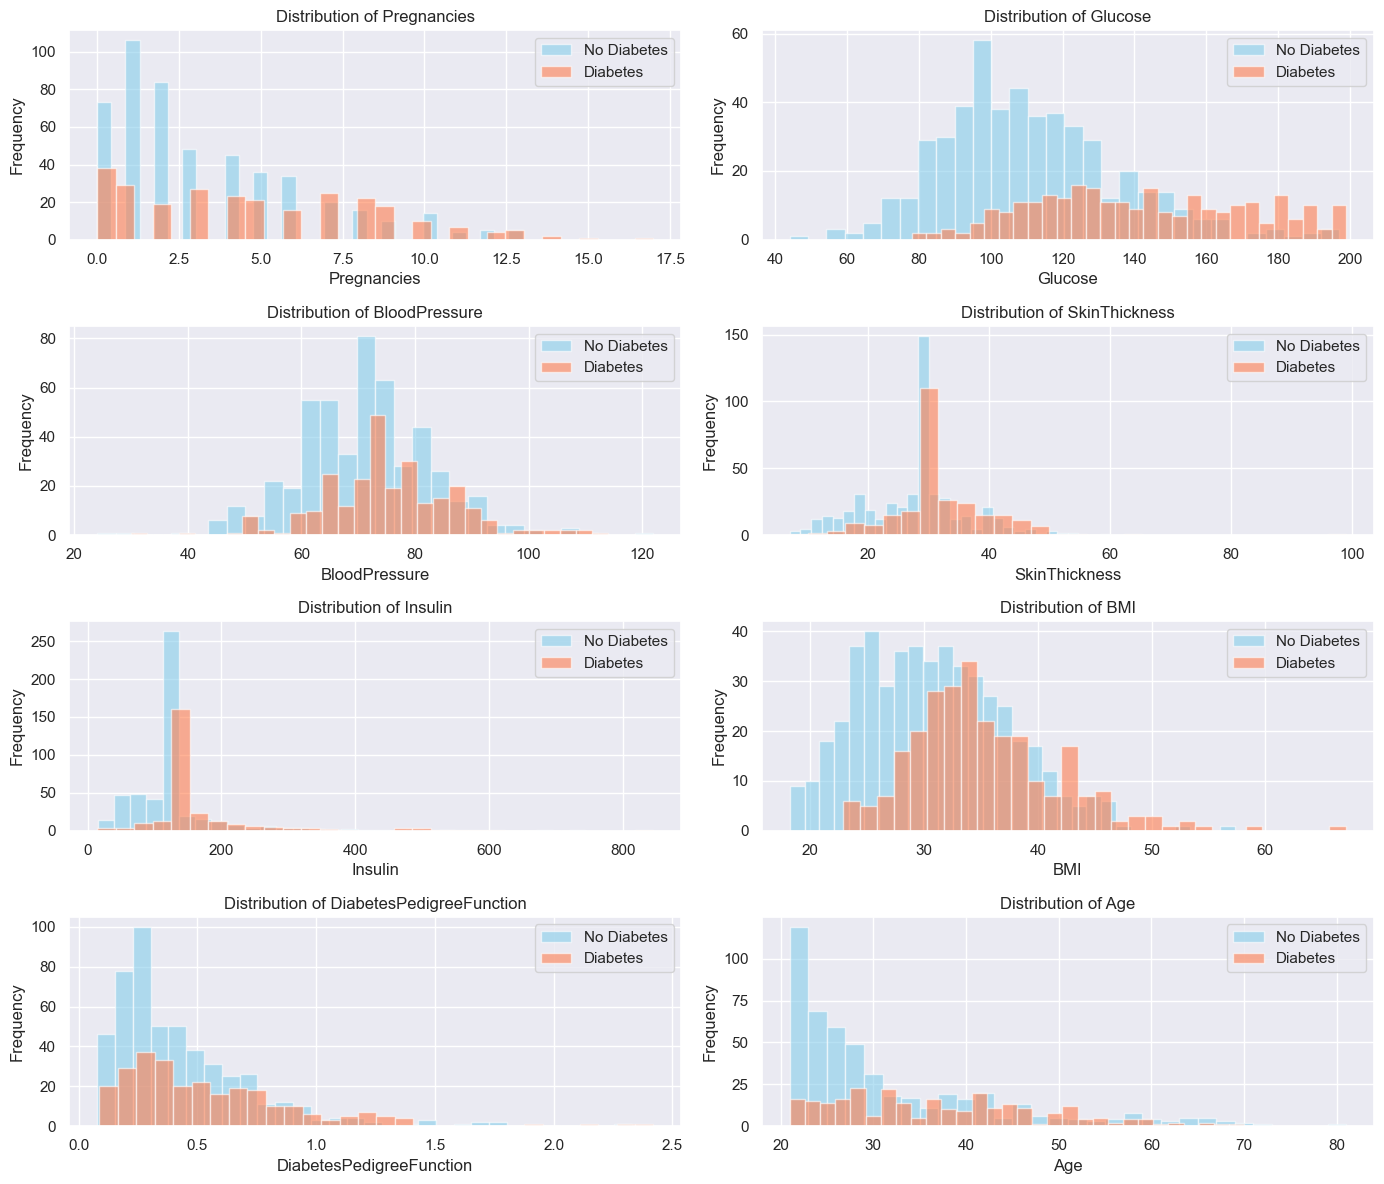

Feature distributions analyzed


In [6]:
# Feature distributions by outcome
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, feature in enumerate(features):
    # Create histograms for each class
    df[df['Outcome'] == 0][feature].hist(bins=30, alpha=0.6, label='No Diabetes', ax=axes[idx], color='skyblue')
    df[df['Outcome'] == 1][feature].hist(bins=30, alpha=0.6, label='Diabetes', ax=axes[idx], color='coral')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print('Feature distributions analyzed')

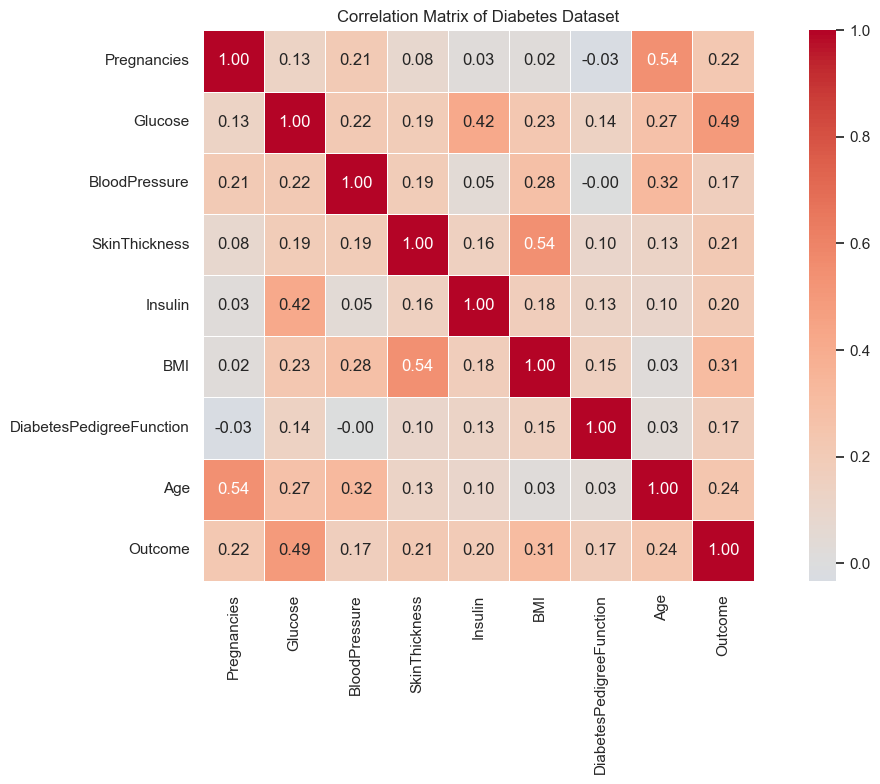


Top correlations with Outcome:
Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


In [7]:
# Correlation analysis
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Diabetes Dataset')
plt.tight_layout()
plt.show()

print('\nTop correlations with Outcome:')
print(correlation_matrix['Outcome'].sort_values(ascending=False))

## 5. Data Preparation

In [8]:
# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature names:', X.columns.tolist())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTraining set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')
print(f'\nTraining set - Diabetes cases: {y_train.sum()} / {len(y_train)} ({y_train.sum()/len(y_train)*100:.1f}%)')
print(f'Testing set - Diabetes cases: {y_test.sum()} / {len(y_test)} ({y_test.sum()/len(y_test)*100:.1f}%)')

Features shape: (768, 8)
Target shape: (768,)

Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Training set size: 614
Testing set size: 154

Training set - Diabetes cases: 214 / 614 (34.9%)
Testing set - Diabetes cases: 54 / 154 (35.1%)


In [9]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Data scaled using StandardScaler')
print(f'\nX_train_scaled mean: {X_train_scaled.mean(axis=0).round(3)}')
print(f'X_train_scaled std: {X_train_scaled.std(axis=0).round(3)}')

Data scaled using StandardScaler

X_train_scaled mean: [-0. -0.  0. -0. -0. -0. -0. -0.]
X_train_scaled std: [1. 1. 1. 1. 1. 1. 1. 1.]


## 6. KNN Classification with Hyperparameter Tuning

In [10]:
# Define hyperparameter grid for GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

print('Hyperparameter Grid:')
print(f'n_neighbors: {param_grid["n_neighbors"]}')
print(f'weights: {param_grid["weights"]}')
print(f'metric: {param_grid["metric"]}')
print(f'\nTotal combinations: {len(param_grid["n_neighbors"]) * len(param_grid["weights"]) * len(param_grid["metric"])}')

Hyperparameter Grid:
n_neighbors: [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
weights: ['uniform', 'distance']
metric: ['euclidean', 'manhattan', 'minkowski']

Total combinations: 60


In [11]:
# Initialize base KNN classifier
knn = KNeighborsClassifier()

# Perform GridSearchCV
print('Starting GridSearchCV...')
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print('\nGridSearchCV completed!')

Starting GridSearchCV...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

GridSearchCV completed!


In [12]:
# Get best parameters
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_model = grid_search.best_estimator_

print('\n' + '='*50)
print('BEST HYPERPARAMETERS')
print('='*50)
print(f'n_neighbors: {best_params["n_neighbors"]}')
print(f'weights: {best_params["weights"]}')
print(f'metric: {best_params["metric"]}')
print(f'\nBest CV Score (Accuracy): {best_score:.4f}')
print('='*50)


BEST HYPERPARAMETERS
n_neighbors: 19
weights: uniform
metric: euclidean

Best CV Score (Accuracy): 0.7769


In [13]:
# Display top 10 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[['param_n_neighbors', 'param_weights', 'param_metric', 'mean_test_score', 'std_test_score']]
results_df = results_df.sort_values('mean_test_score', ascending=False)
results_df.columns = ['n_neighbors', 'weights', 'metric', 'mean_accuracy', 'std_accuracy']

print('\nTop 10 Parameter Combinations:')
print(results_df.head(10).to_string(index=False))


Top 10 Parameter Combinations:
n_neighbors  weights    metric  mean_accuracy  std_accuracy
         19  uniform minkowski       0.776903      0.027269
         19  uniform euclidean       0.776903      0.027269
         19 distance manhattan       0.775250      0.022698
         19 distance minkowski       0.773651      0.032047
         19 distance euclidean       0.773651      0.032047
         21  uniform minkowski       0.773637      0.019263
         21  uniform euclidean       0.773637      0.019263
         19  uniform manhattan       0.773611      0.022687
         17 distance minkowski       0.772025      0.029717
         17 distance euclidean       0.772025      0.029717


## 7. Model Evaluation

In [14]:
# Make predictions
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)

# Get prediction probabilities for ROC-AUC
y_test_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print('Predictions made on training and testing sets')

Predictions made on training and testing sets


In [15]:
# Calculate evaluation metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print('\n' + '='*50)
print('MODEL PERFORMANCE METRICS')
print('='*50)
print(f'Training Accuracy: {train_accuracy:.4f}')
print(f'Testing Accuracy:  {test_accuracy:.4f}')
print(f'\nTesting Set Metrics:')
print(f'  Precision: {test_precision:.4f}')
print(f'  Recall:    {test_recall:.4f}')
print(f'  F1 Score:  {test_f1:.4f}')
print(f'  ROC-AUC:   {test_roc_auc:.4f}')
print('='*50)


MODEL PERFORMANCE METRICS
Training Accuracy: 0.8029
Testing Accuracy:  0.7468

Testing Set Metrics:
  Precision: 0.6667
  Recall:    0.5556
  F1 Score:  0.6061
  ROC-AUC:   0.8077


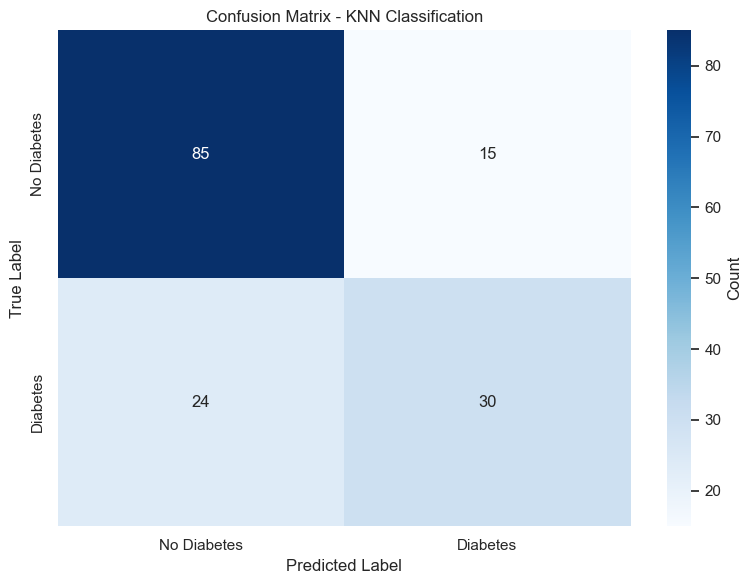


Confusion Matrix:
[[85 15]
 [24 30]]

True Negatives:  85
False Positives: 15
False Negatives: 24
True Positives:  30


In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            cbar_kws={'label': 'Count'},
            ax=ax)
ax.set_title('Confusion Matrix - KNN Classification')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print('\nConfusion Matrix:')
print(cm)
print(f'\nTrue Negatives:  {cm[0,0]}')
print(f'False Positives: {cm[0,1]}')
print(f'False Negatives: {cm[1,0]}')
print(f'True Positives:  {cm[1,1]}')

In [17]:
# Classification Report
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_test_pred, 
                          target_names=['No Diabetes', 'Diabetes']))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Diabetes       0.78      0.85      0.81       100
    Diabetes       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



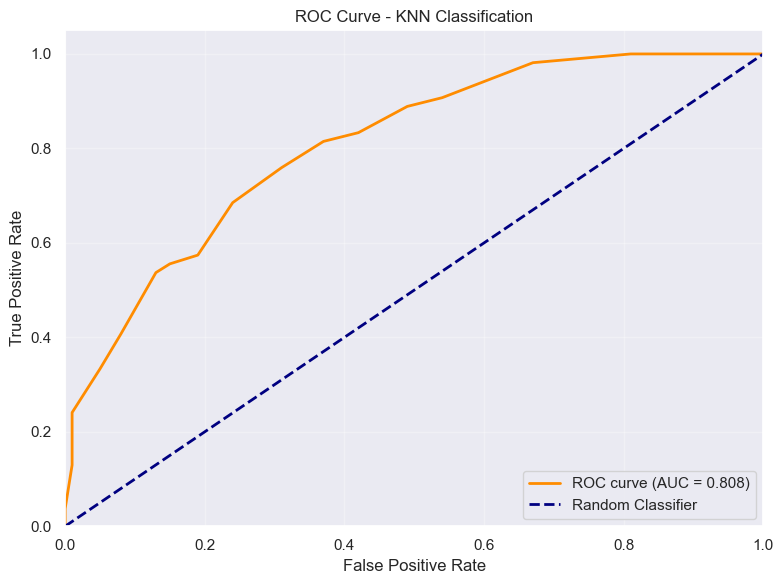

ROC Curve plotted


In [18]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - KNN Classification')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('ROC Curve plotted')

## 8. Save Model and Artifacts

In [19]:
# Create models directory if it doesn't exist
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

# Save the best model
model_path = os.path.join(models_dir, 'knn_classifier.pkl')
joblib.dump(best_model, model_path)
print(f'✓ Model saved: {model_path}')

# Save the scaler
scaler_path = os.path.join(models_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'✓ Scaler saved: {scaler_path}')

# Save feature names
feature_names_path = os.path.join(models_dir, 'feature_names.pkl')
joblib.dump(X.columns.tolist(), feature_names_path)
print(f'✓ Feature names saved: {feature_names_path}')

# Save best hyperparameters and metrics
hyperparams_path = os.path.join(models_dir, 'hyperparameters.pkl')
hyperparams_dict = {
    'best_params': best_params,
    'best_cv_score': best_score,
    'train_accuracy': train_accuracy,
    'test_accuracy': test_accuracy,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'test_f1': test_f1,
    'test_roc_auc': test_roc_auc
}
joblib.dump(hyperparams_dict, hyperparams_path)
print(f'✓ Hyperparameters and metrics saved: {hyperparams_path}')

print('\n✓ All model artifacts saved successfully!')

✓ Model saved: ..\models\knn_classifier.pkl
✓ Scaler saved: ..\models\scaler.pkl
✓ Feature names saved: ..\models\feature_names.pkl
✓ Hyperparameters and metrics saved: ..\models\hyperparameters.pkl

✓ All model artifacts saved successfully!


## 9. Summary

In [20]:
print('\n' + '='*70)
print('DIABETES KNN CLASSIFICATION - SUMMARY')
print('='*70)
print(f'\nDataset: diabetes.csv')
print(f'Total samples: {len(df)}')
print(f'Number of features: {X.shape[1]}')
print(f'Target variable: Outcome (Binary - 0: No Diabetes, 1: Diabetes)')

print(f'\nData Split:')
print(f'  Training set: {X_train.shape[0]} samples')
print(f'  Testing set: {X_test.shape[0]} samples')

print(f'\nOptimal Hyperparameters Found:')
print(f'  n_neighbors: {best_params["n_neighbors"]}')
print(f'  weights: {best_params["weights"]}')
print(f'  metric: {best_params["metric"]}')

print(f'\nModel Performance:')
print(f'  Training Accuracy: {train_accuracy:.4f}')
print(f'  Testing Accuracy:  {test_accuracy:.4f}')
print(f'  Precision: {test_precision:.4f}')
print(f'  Recall:    {test_recall:.4f}')
print(f'  F1 Score:  {test_f1:.4f}')
print(f'  ROC-AUC:   {test_roc_auc:.4f}')

print(f'\nModel Status: ✓ TRAINED AND SAVED')
print('='*70)


DIABETES KNN CLASSIFICATION - SUMMARY

Dataset: diabetes.csv
Total samples: 768
Number of features: 8
Target variable: Outcome (Binary - 0: No Diabetes, 1: Diabetes)

Data Split:
  Training set: 614 samples
  Testing set: 154 samples

Optimal Hyperparameters Found:
  n_neighbors: 19
  weights: uniform
  metric: euclidean

Model Performance:
  Training Accuracy: 0.8029
  Testing Accuracy:  0.7468
  Precision: 0.6667
  Recall:    0.5556
  F1 Score:  0.6061
  ROC-AUC:   0.8077

Model Status: ✓ TRAINED AND SAVED
